## This project focuses on developing a predictive model that uses historical sales data from different stores to forecast sales for upcoming periods

In [1]:
import pandas as pd
import numpy as np

import seaborn as sns

import matplotlib.pyplot as plt

import statsmodels.api as sm
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.model_selection import TimeSeriesSplit

from statsmodels.tsa.stattools import adfuller
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error

import warnings
warnings.filterwarnings('ignore')

In [2]:
plt.rcParams['figure.figsize'] = (20,6)

Below codes helps in loading required files

In [3]:
!gdown --fuzzy "https://drive.google.com/file/d/1n6oNHD6CxIfTVQddNWEMENx2aYC6yDup/view?usp=sharing"

Downloading...
From: https://drive.google.com/uc?id=1n6oNHD6CxIfTVQddNWEMENx2aYC6yDup
To: /content/TEST_FINAL.csv
100% 849k/849k [00:00<00:00, 20.1MB/s]


In [4]:
test_df = pd.read_csv("/content/TEST_FINAL.csv")

In [5]:
!gdown --fuzzy "https://drive.google.com/file/d/1Q1C5wE5ShbZgJ8yLaYWIIzT-CEJ2mUzS/view?usp=sharing"

Downloading...
From: https://drive.google.com/uc?id=1Q1C5wE5ShbZgJ8yLaYWIIzT-CEJ2mUzS
To: /content/TRAIN.csv
100% 9.33M/9.33M [00:00<00:00, 27.1MB/s]


In [6]:
train_df = pd.read_csv("/content/TRAIN.csv")

In [7]:
train_df.head(10)

,ID,Store_id,Store_Type,Location_Type,Region_Code,Date,Holiday,Discount,#Order,Sales
0,T1000001,1,S1,L3,R1,2018-01-01,1,Yes,9,7011.84
1,T1000002,253,S4,L2,R1,2018-01-01,1,Yes,60,51789.12
2,T1000003,252,S3,L2,R1,2018-01-01,1,Yes,42,36868.20
3,T1000004,251,S2,L3,R1,2018-01-01,1,Yes,23,19715.16
4,T1000005,250,S2,L3,R4,2018-01-01,1,Yes,62,45614.52
5,T1000006,249,S1,L3,R2,2018-01-01,1,Yes,39,34211.22
6,T1000007,248,S1,L1,R2,2018-01-01,1,Yes,40,35352.66
7,T1000008,247,S1,L1,R3,2018-01-01,1,Yes,64,52650.00
8,T1000009,246,S3,L1,R3,2018-01-01,1,Yes,62,42633.78
9,T1000010,254,S4,L1,R1,2018-01-01,1,Yes,87,62572.80


In [8]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 188340 entries, 0 to 188339
Data columns (total 10 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   ID             188340 non-null  object 
 1   Store_id       188340 non-null  int64  
 2   Store_Type     188340 non-null  object 
 3   Location_Type  188340 non-null  object 
 4   Region_Code    188340 non-null  object 
 5   Date           188340 non-null  object 
 6   Holiday        188340 non-null  int64  
 7   Discount       188340 non-null  object 
 8   #Order         188340 non-null  int64  
 9   Sales          188340 non-null  float64
dtypes: float64(1), int64(3), object(6)
memory usage: 14.4+ MB


From above we can see that it has 10 columns - float(1), int64(3), object(6), while have 188349 numbers of rows without any NaN rows

In [9]:
train_df.describe()

,Store_id,Holiday,#Order,Sales
count,188340.000000,188340.000000,188340.000000,188340.000000
mean,183.000000,0.131783,68.205692,42784.327982
std,105.366308,0.338256,30.467415,18456.708302
min,1.000000,0.000000,0.000000,0.000000
25%,92.000000,0.000000,48.000000,30426.000000
50%,183.000000,0.000000,63.000000,39678.000000
75%,274.000000,0.000000,82.000000,51909.000000
max,365.000000,1.000000,371.000000,247215.000000


In [10]:
train_df.describe(include = 'O')

,ID,Store_Type,Location_Type,Region_Code,Date,Discount
count,188340,188340,188340,188340,188340,188340
unique,188340,4,5,4,516,2
top,T1188340,S1,L1,R1,2019-05-31,No
freq,1,88752,85140,63984,365,104051


In [11]:
for k in train_df.columns.tolist():
  if train_df[k].nunique() < 10:
    print()
    print(f"{k} : Unique >> {train_df[k].unique()} | No. of Unique >> {train_df[k].nunique()}")
  else:
    print(f"{k} column have unique values more than 10")

ID column have unique values more than 10
Store_id column have unique values more than 10

Store_Type : Unique >> ['S1' 'S4' 'S3' 'S2'] | No. of Unique >> 4

Location_Type : Unique >> ['L3' 'L2' 'L1' 'L5' 'L4'] | No. of Unique >> 5

Region_Code : Unique >> ['R1' 'R4' 'R2' 'R3'] | No. of Unique >> 4
Date column have unique values more than 10

Holiday : Unique >> [1 0] | No. of Unique >> 2

Discount : Unique >> ['Yes' 'No'] | No. of Unique >> 2
#Order column have unique values more than 10
Sales column have unique values more than 10


From above code, we are trying to show how many count of unique values each column have and if the count of values are less than 10 then we show unique values along respective columns

In [12]:
train_df.duplicated().sum()

np.int64(0)

Above cell help in find duplicate values along whole data frame but as per current situation we don't have any

In [13]:
train_df.isna().sum()

,0
ID,0
Store_id,0
Store_Type,0
Location_Type,0
Region_Code,0
Date,0
Holiday,0
Discount,0
#Order,0
Sales,0


Above code helps us in finding missing (NaN) values along different columns

## EDA

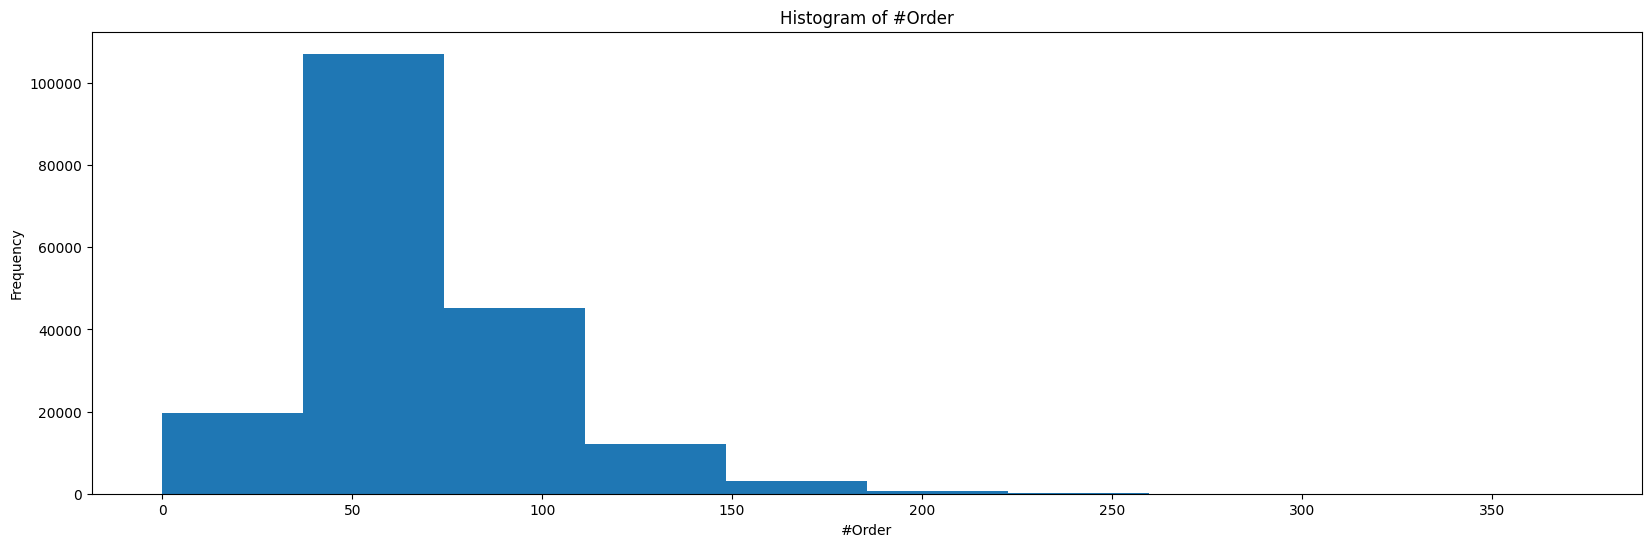

In [14]:
train_df['#Order'].plot(kind = 'hist')

plt.xlabel("#Order")
plt.title("Histogram of #Order")
plt.show()

Above histogram help us in understanding were majority of orders resides and we can see that it between 40 to 75 (approx) along with few outliers

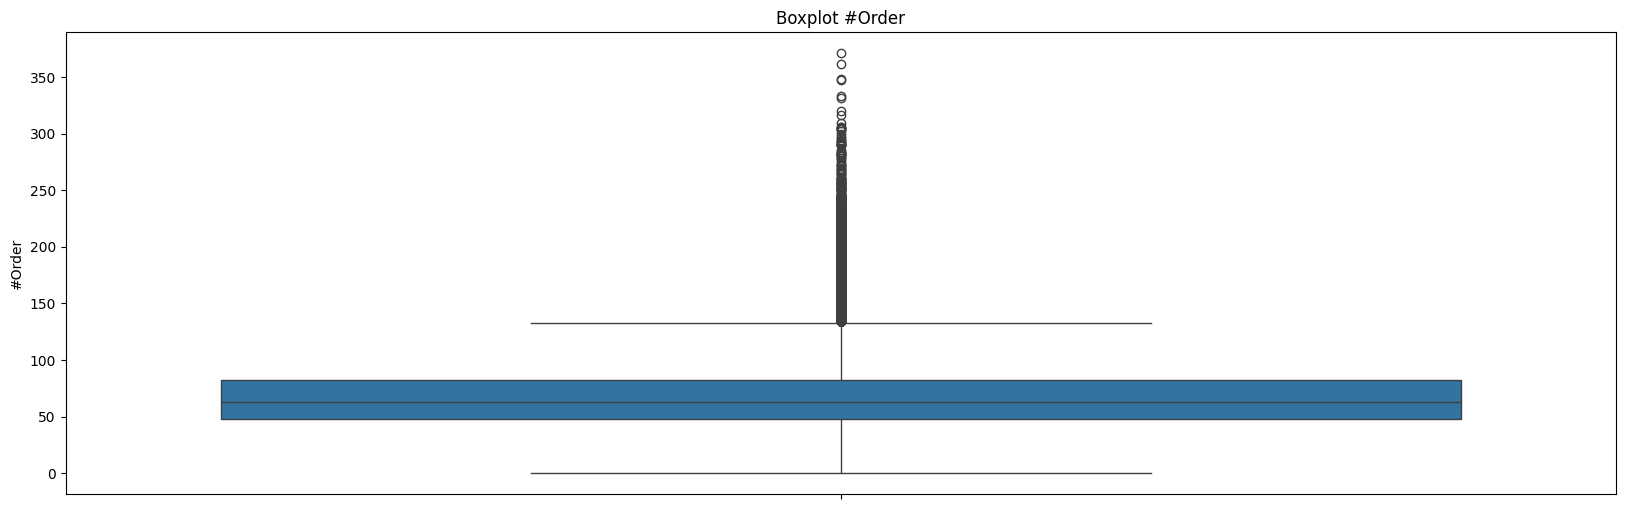

In [15]:
sns.boxplot(train_df['#Order'])

plt.title("Boxplot #Order")
plt.show()

Boxplot helps us in knowing Median value along with IQR range and outliers impact. Here we can see outliers show impact, meaning #Order column do have few outliers.

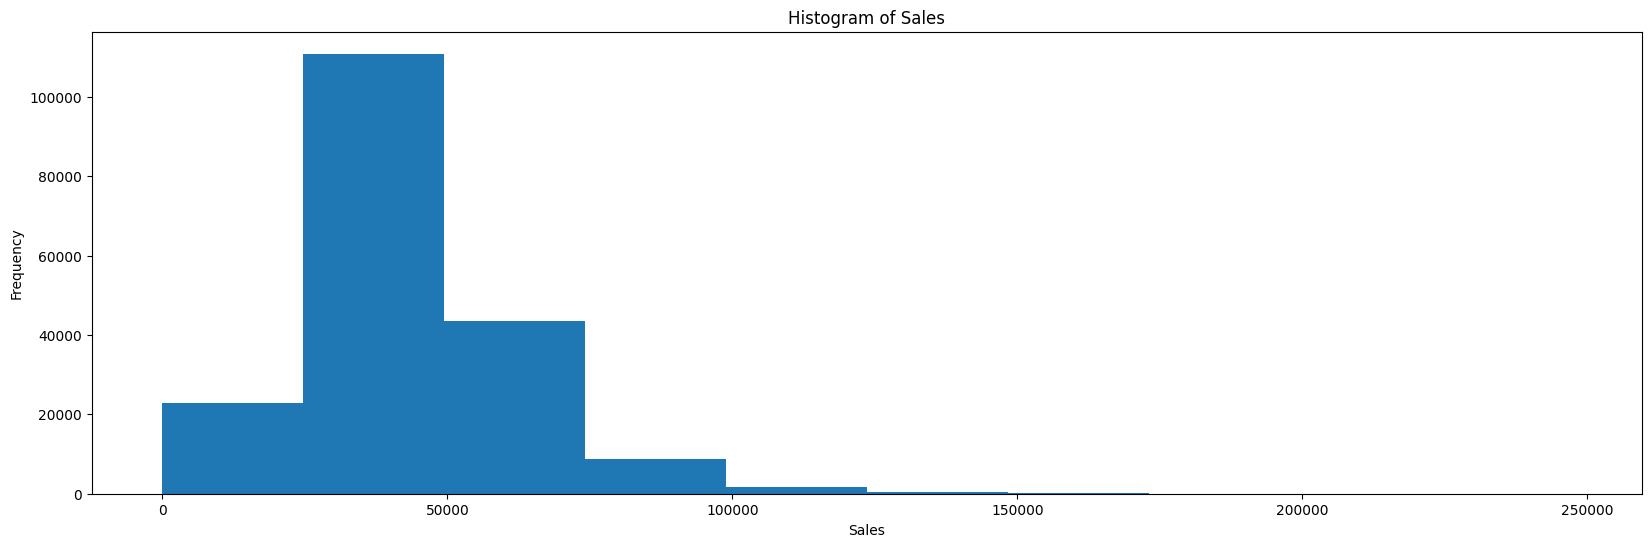

In [16]:
train_df['Sales'].plot(kind = 'hist')

plt.xlabel("Sales")
plt.title("Histogram of Sales")
plt.show()

Above histogram of Sales columns help us understand distribution along it. We can see majority of data point lies between 25000 to 75000 (approx).

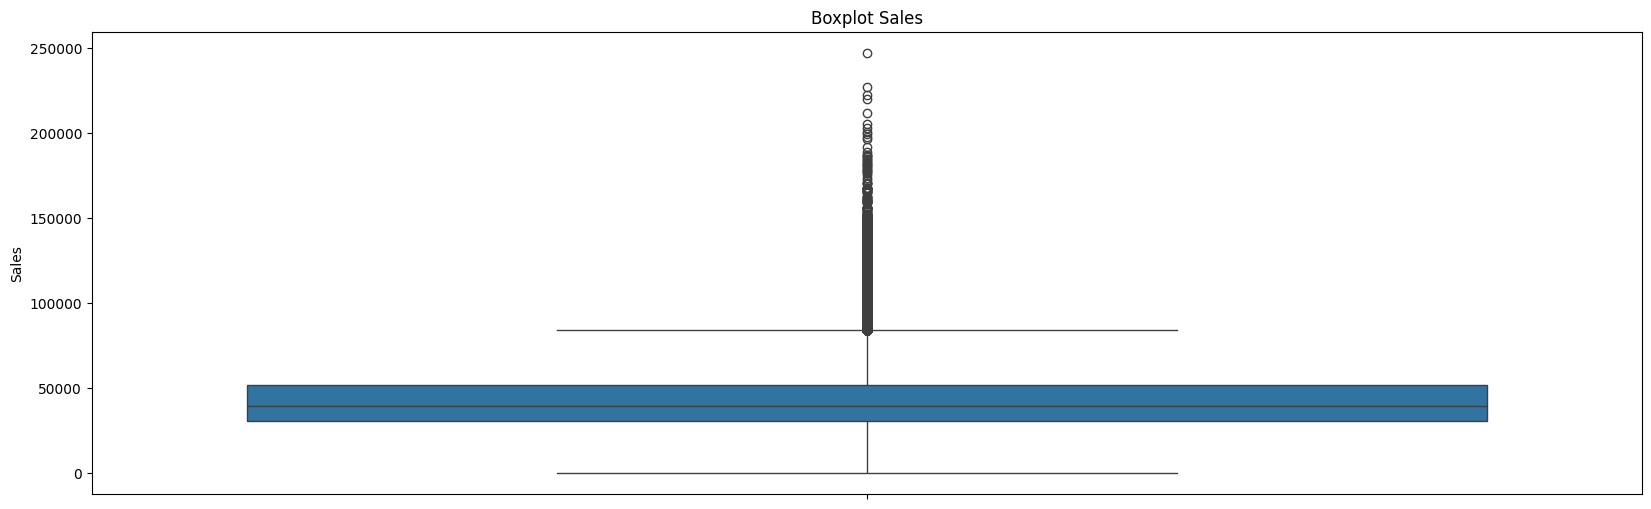

In [17]:
sns.boxplot(train_df['Sales'])

plt.title("Boxplot Sales")
plt.show()

Boxplot help us understand presence of outliers along with IQR and Median. Here alos Sales column contains few outliers shown by points above Upper limit.

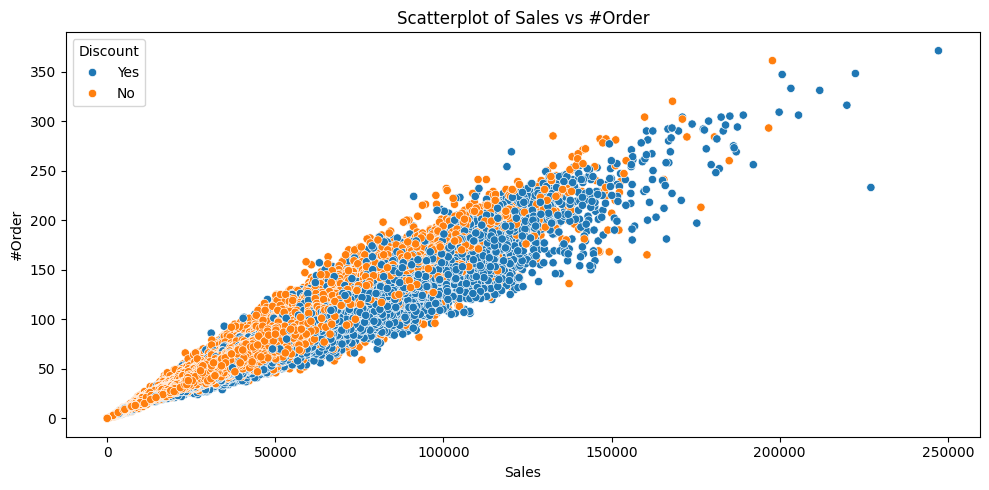

In [18]:
plt.figure(figsize = (10, 5))

sns.scatterplot(x = 'Sales', y = '#Order', data = train_df, hue = 'Discount')

plt.title("Scatterplot of Sales vs #Order")
plt.tight_layout()
plt.show()

Above scatterplot helps us understand correlation of #Order and Sales, as we can see when orders increases then Sales also increase showing upward possitive correlation. We can also see when discounts are provided then sales show minor impact accordingly.

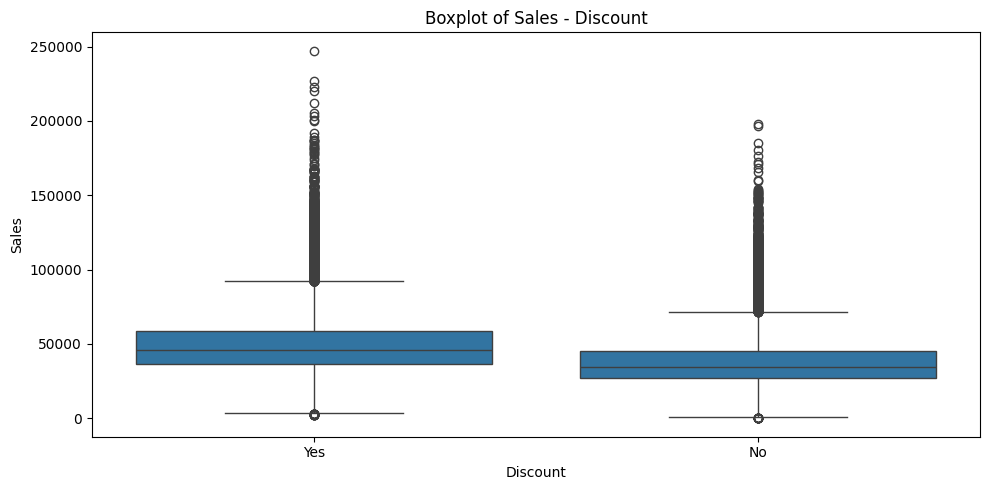

In [19]:
plt.figure(figsize = (10, 5))

sns.boxplot(x = 'Discount', y = 'Sales', data = train_df)

plt.title("Boxplot of Sales - Discount")
plt.tight_layout()
plt.show()

Above boxplot help us understand distribution of sales along when discount was provided or not provided. Based on Median values we can see when Discount was provided then median sales were high (having more outliers) while when Discount was not provided then median sales are getting impact (having less outliers compared to when discount was provided).

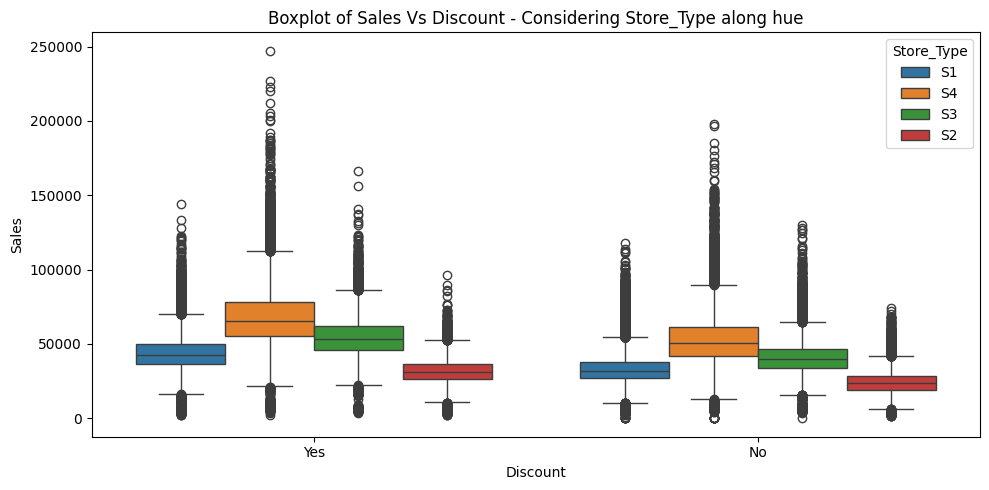

In [20]:
plt.figure(figsize = (10, 5))

sns.boxplot(x = 'Discount', y = 'Sales', data = train_df, hue = 'Store_Type')

plt.title("Boxplot of Sales Vs Discount - Considering Store_Type along hue")
plt.tight_layout()
plt.show()

Above boxplot help us understand influence of Discount along different Store type with Sales. Here we all can see S4 leads the ranking along both when we consider median value.

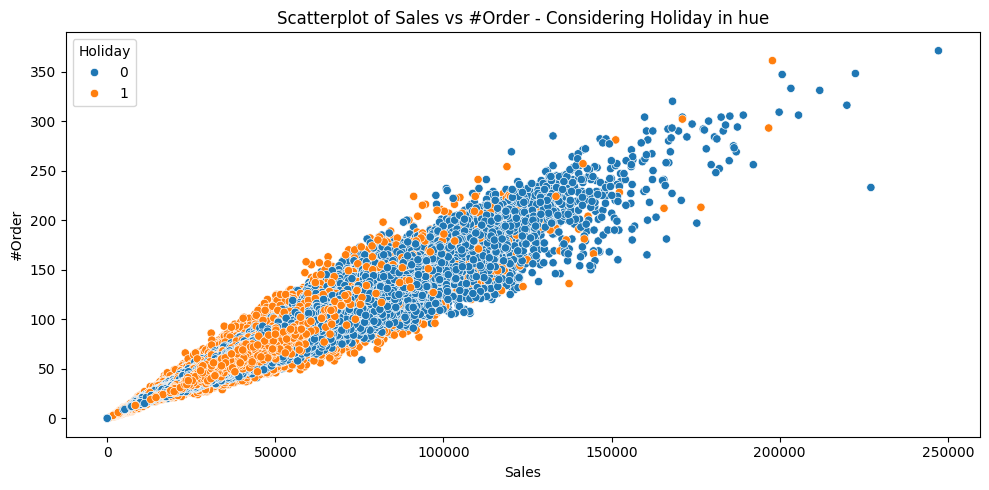

In [21]:
plt.figure(figsize = (10, 5))

sns.scatterplot(x = 'Sales', y = '#Order', data = train_df, hue = 'Holiday')

plt.title("Scatterplot of Sales vs #Order - Considering Holiday in hue")
plt.tight_layout()
plt.show()

Above scatterplot between Orders and Sales while considering Holiday along hue provides deep understand on how our order along with sales are gettign impacted when their is holiday or not. More value of sales and order can be see when their is no holiday while less value of sales along with order when their is holiday

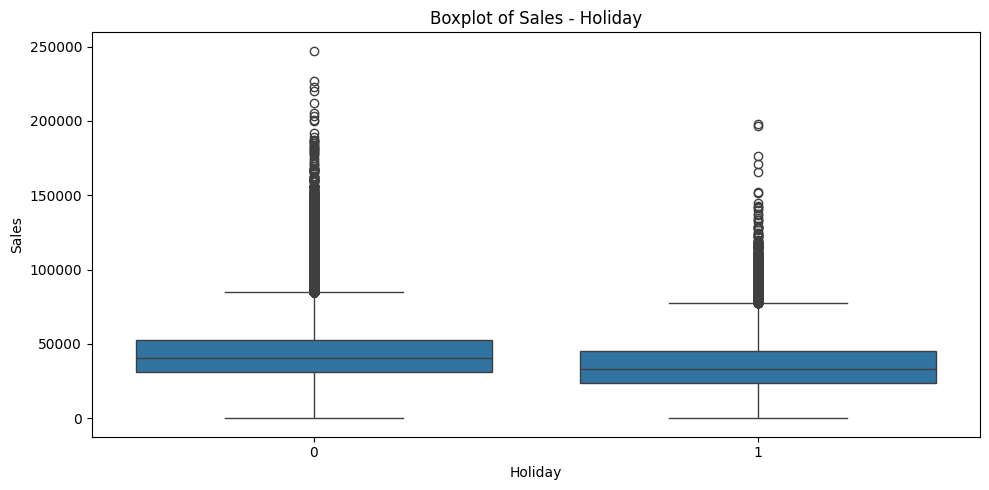

In [22]:
plt.figure(figsize = (10, 5))

sns.boxplot(x = 'Holiday', y = 'Sales', data = train_df)

plt.title("Boxplot of Sales - Holiday")
plt.tight_layout()
plt.show()

Above boxplot provides a deep understanding of how our sales is being shown along holiday. When we have holiday then our sales are less as compared to when we don't have holiday. Seems like customer prefer shoping during weekdays.

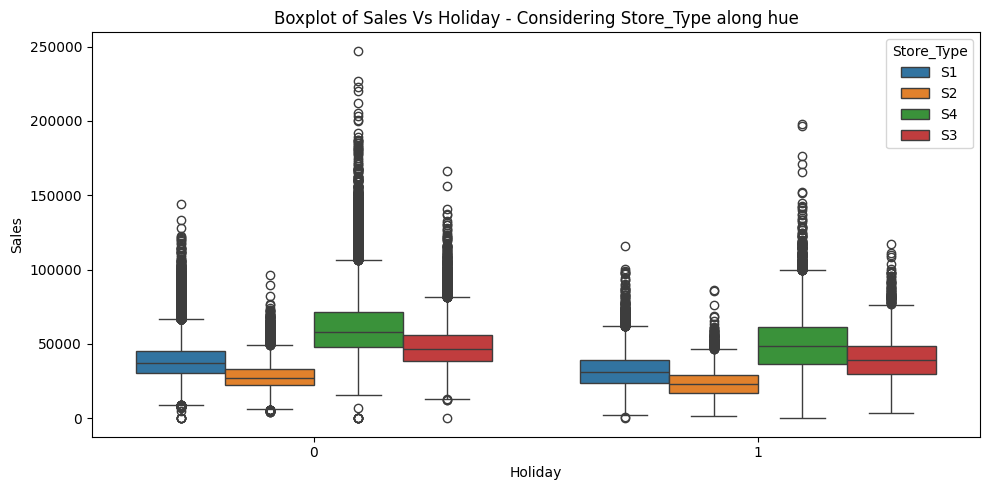

In [23]:
plt.figure(figsize = (10, 5))

sns.boxplot(x = 'Holiday', y = 'Sales', data = train_df, hue = 'Store_Type')

plt.title("Boxplot of Sales Vs Holiday - Considering Store_Type along hue")
plt.tight_layout()
plt.show()

Above boxplot help us understand influence of holiday on sales along different store types. Here we can observe and see store type S4 leads the ranking compared to other stre types along both whether its a holiday or not.

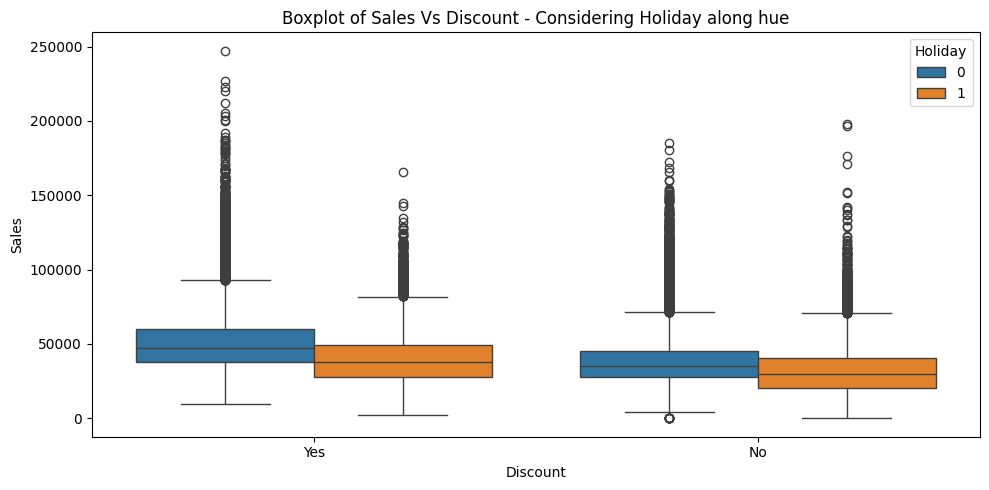

In [24]:
plt.figure(figsize = (10, 5))

sns.boxplot(x = 'Discount', y = 'Sales', data = train_df, hue = 'Holiday')

plt.title("Boxplot of Sales Vs Discount - Considering Holiday along hue")
plt.tight_layout()
plt.show()

Above boxplot provides a deep understanding of influence of discount and holiday along sales. During holiday, when discounts are provided then sales are high while during no-holiday sales are high when discounts are provided.

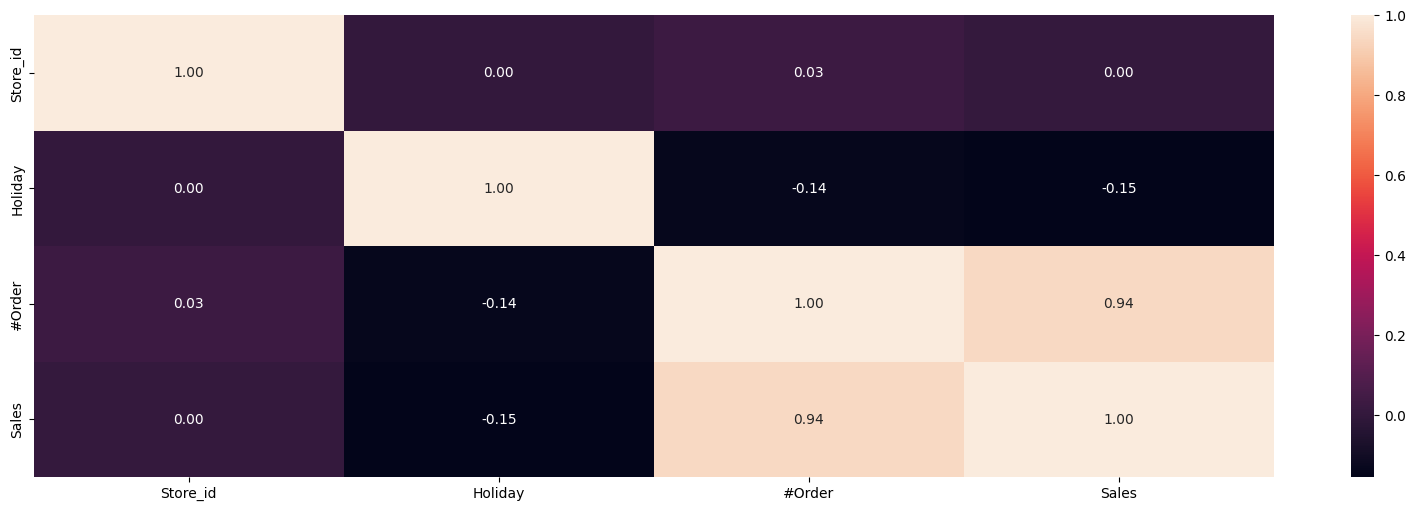

In [25]:
sns.heatmap(train_df.select_dtypes(['int', 'float']).corr(), fmt = '.2f', annot = True)

plt.show()

Above heatmap help us understand correlation beteen different columns along dataframe. Here we can see a very strong positive correlation between sales and orders.

In [26]:
train_df["Date"] = pd.to_datetime(train_df["Date"])

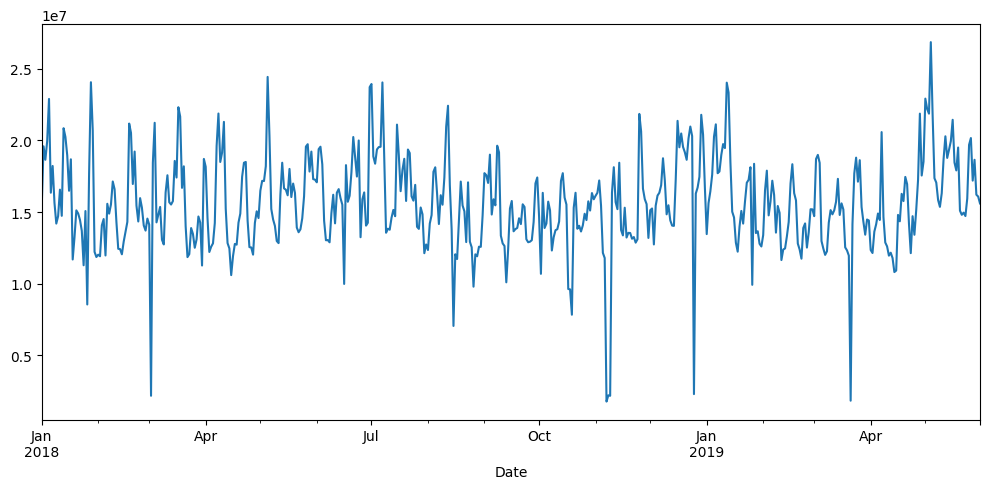

In [27]:
plt, fig = plt.subplots(figsize = (10, 5))

train_df.groupby("Date").sum()["Sales"].plot()

plt.tight_layout()
plt.show()

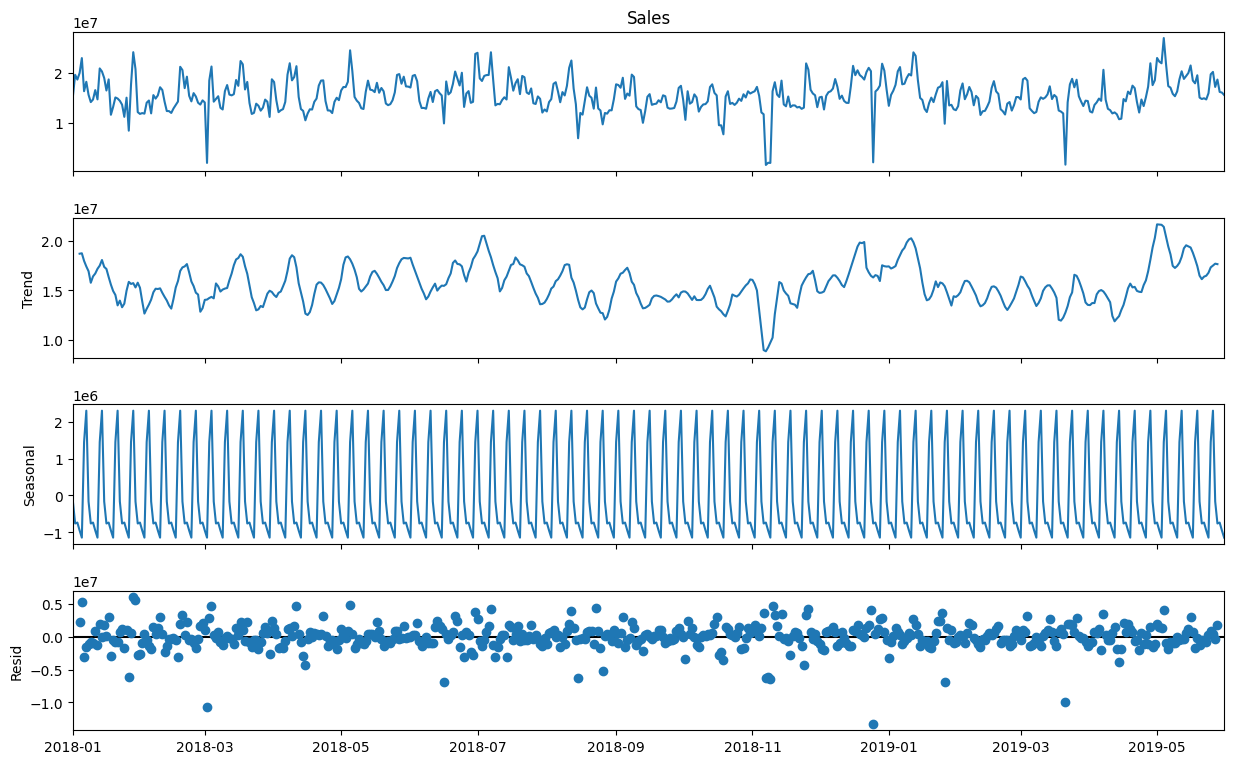

In [28]:
fig = seasonal_decompose(train_df.groupby("Date").sum()["Sales"]).plot()

fig.set_size_inches(12, 8)

plt.tight_layout()
plt.show()

Above seasonal decomposition helps us understand about seasonality, trend, normal time-series line chart and residual fluctuations. We have observed weekly seasonality after aggregating number to rows at date level.

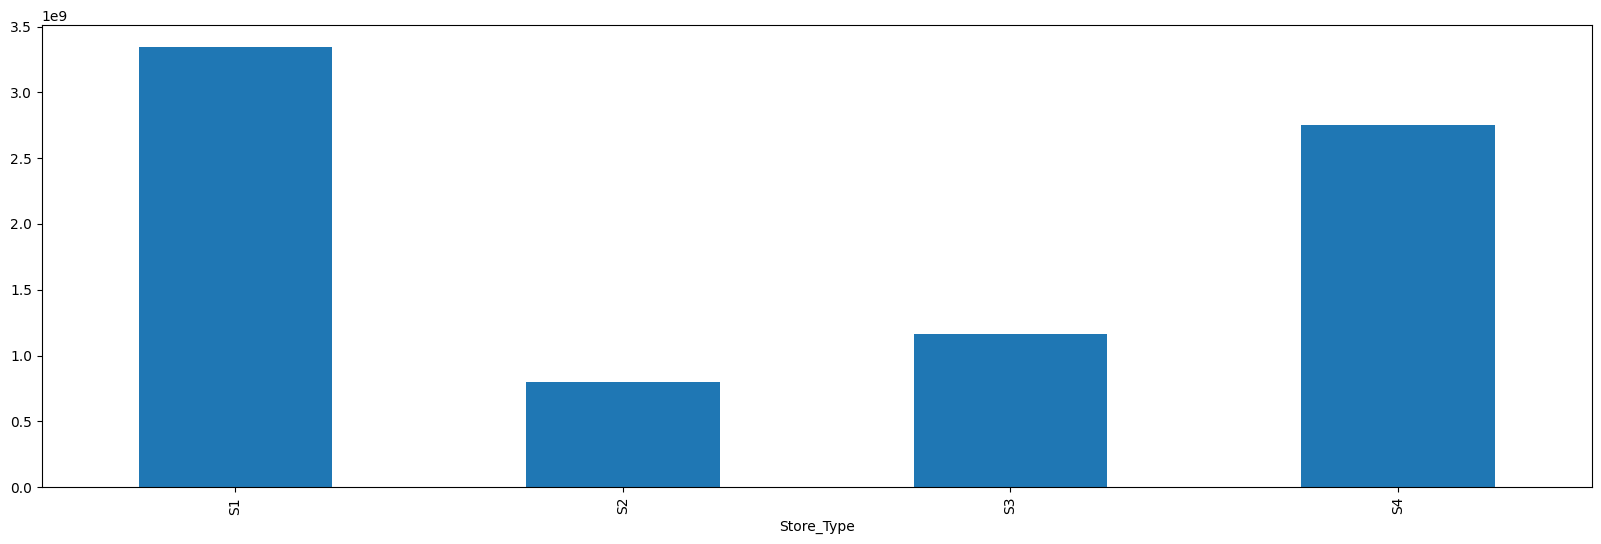

In [29]:
train_df.groupby('Store_Type')['Sales'].sum().plot(kind = 'bar')
plt.show()

After aggregation has been done, above barplot help us understand which Store type is contributing more towards sales and we can see very clearly that S1 leads ranking hlding first position while S4 is ranked second here.

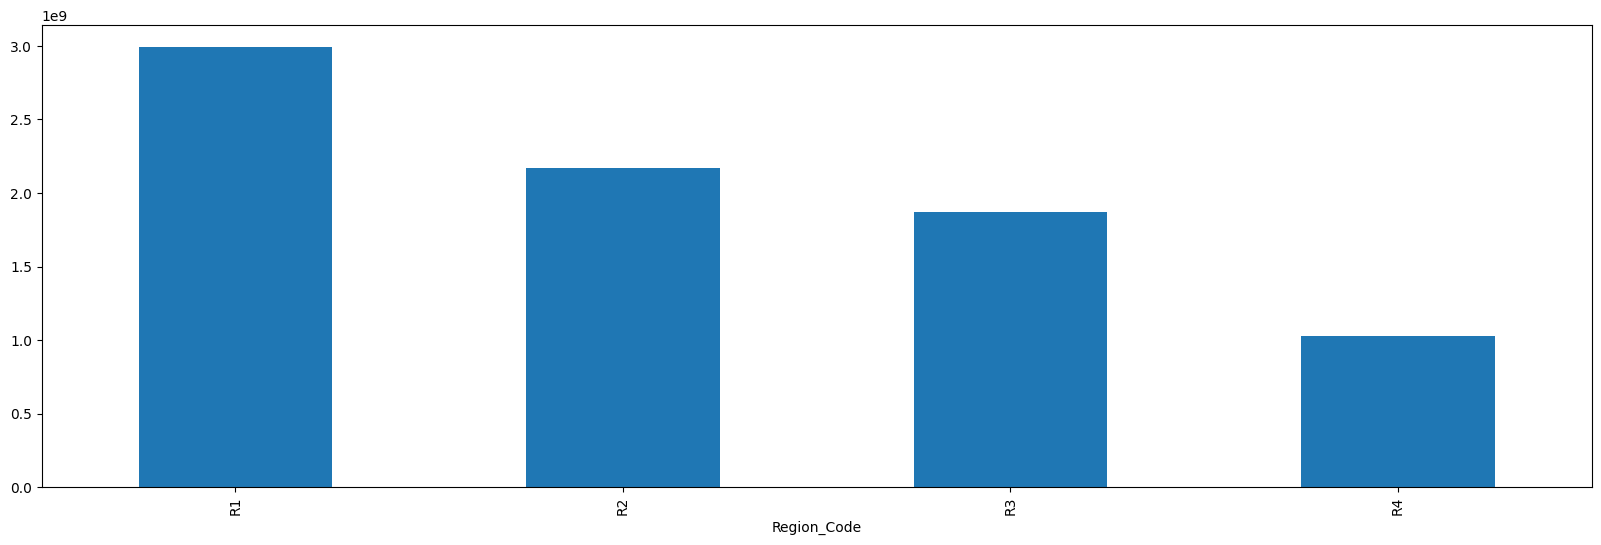

In [30]:
train_df.groupby('Region_Code')['Sales'].sum().plot(kind = 'bar')
plt.show()

Above barplot help us understand major region code contributing high in sales, R1 holds first position while R2 holds second position.

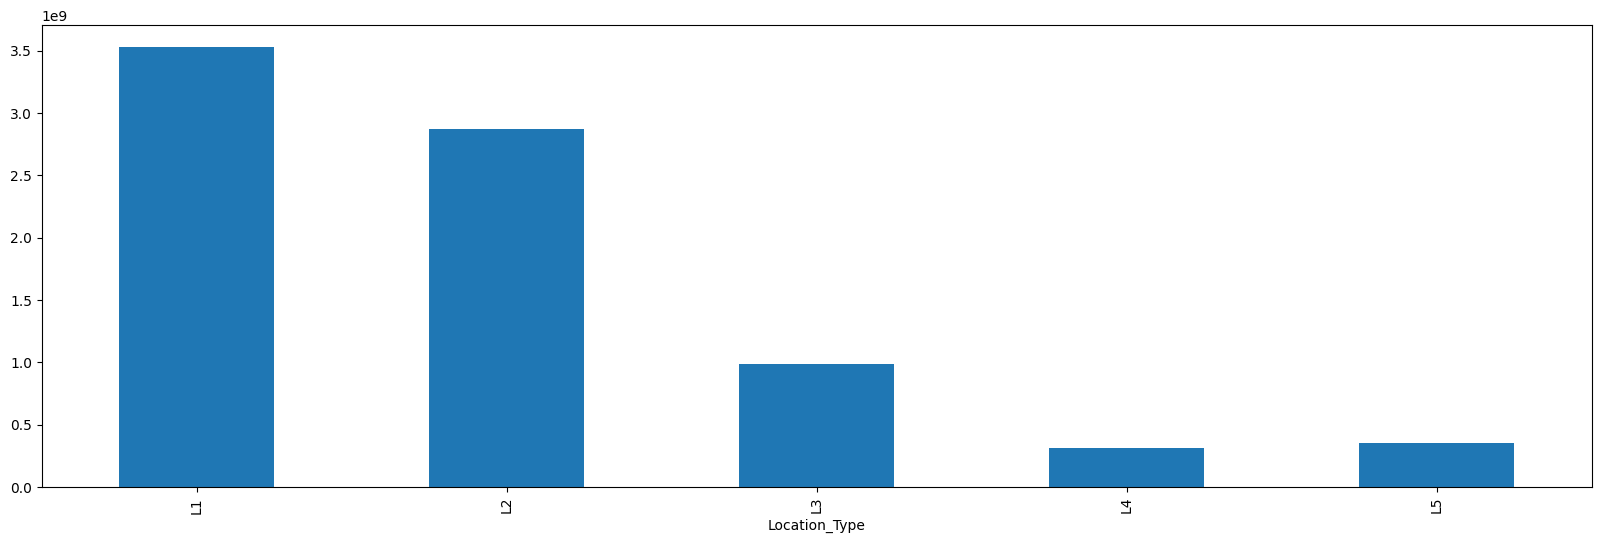

In [31]:
train_df.groupby('Location_Type')['Sales'].sum().plot(kind = 'bar')
plt.show()

After aggregation above barplot help us understand which location type holds first rank, second rank, third rank, forth rank and fifth. L1 ranked 1 followed by L2 ranked 2.

In [32]:
agg_df = train_df.groupby('Date')['Sales'].sum().reset_index().set_index('Date')

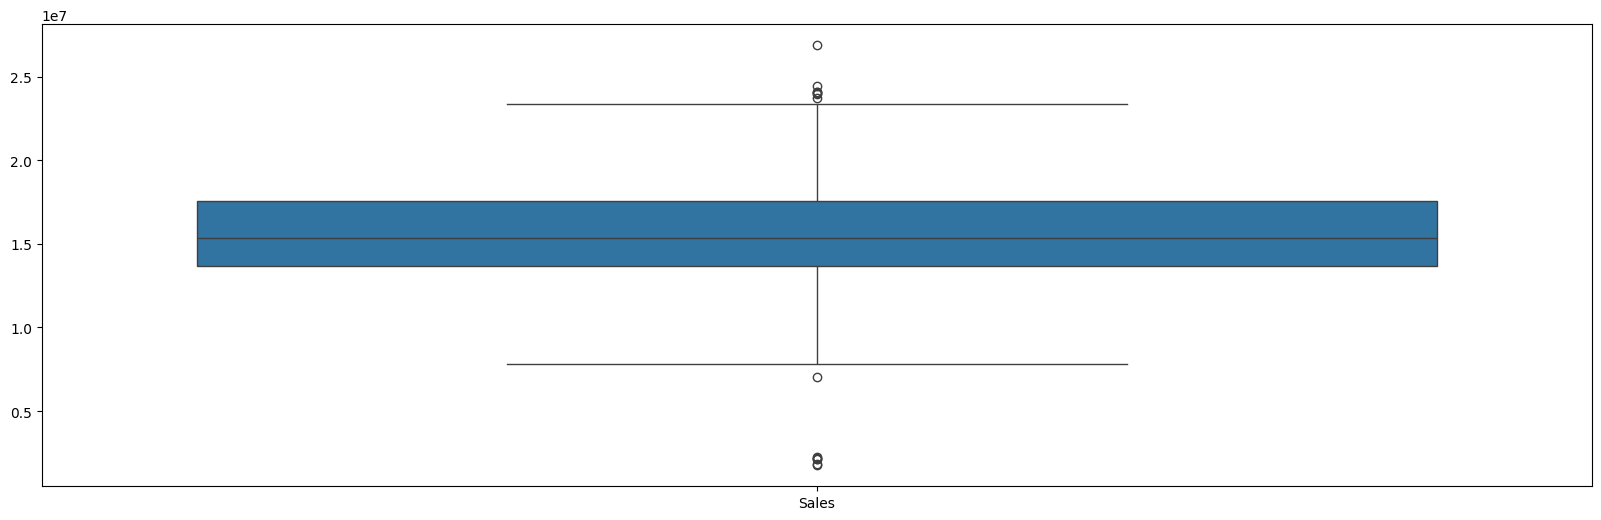

In [33]:
sns.boxplot(data = agg_df)
plt.show()

Above boxplot help us understand presence outliers along sales so to later perform clipping which helps them to remove.

In [34]:
lower = agg_df['Sales'].quantile(0.03)
upper = agg_df['Sales'].quantile(0.97)

agg_df['Sales'] = np.clip(agg_df['Sales'], lower, upper)

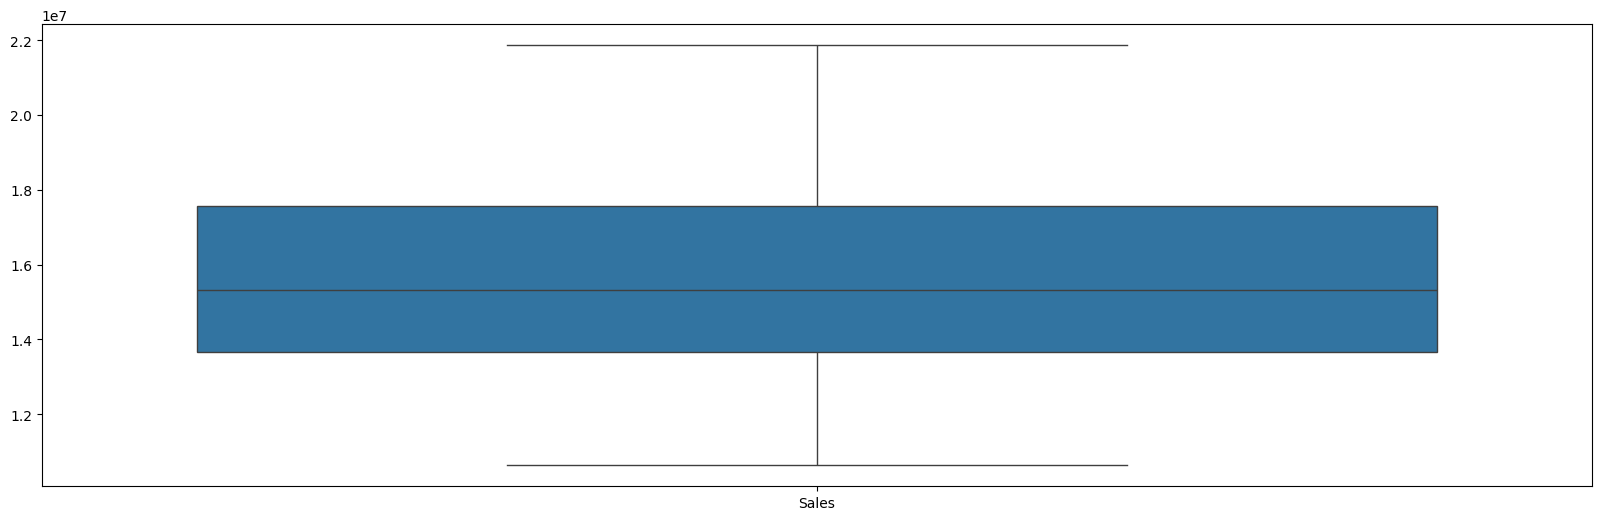

In [35]:
sns.boxplot(data = agg_df)
plt.show()

Above boxplot shows impact of clipping, how this has improved our input dataset.

## Impact of Discounts on Sales

H0 : Discount has no impact on sales (means equal)
H1 : Discount increases sales

In [36]:
no_discount_sales = train_df[train_df['Discount'] == 'No']['Sales']
discount_sales = train_df[train_df['Discount'] == 'Yes']['Sales']

In [37]:
from scipy.stats import ttest_ind

stat, p = ttest_ind(discount_sales, no_discount_sales, equal_var=False)

In [38]:
if p < 0.05:
  print("Reject H0 -> Discount increases sales")
else:
  print("Falied to reject H0 -> Discount has no impact on sales")

Reject H0 -> Discount increases sales


Above hypthesis test help us explain whether is their any impact of discounts on sales and based on results we can see discount has positive impact on sales.

## Effect of Holidays on Sales

H0 : Sales on holidays = Sales on non-holidays
H1 : Sales on holidays > non-holidays

In [39]:
holiday_sales = train_df[train_df['Holiday'] == 1]['Sales']
non_holiday_sales = train_df[train_df['Holiday'] == 0]['Sales']

In [40]:
from scipy.stats import ttest_ind

stat, p = ttest_ind(holiday_sales, non_holiday_sales, equal_var=False)

In [41]:
if p < 0.05:
    print("Reject H0 → Holidays increase sales")
else:
    print("Fail to reject H0 → No strong evidence")

Reject H0 → Holidays increase sales


Above hypthesis test help us explain whether is their any effect of holiday on sales and based on results we can see strong evidence saying holiday increase sales.

## Sales Differences Across Store Types

H0 : All store types have same mean sales
H1 : At least one store type differs

In [42]:
groups = [group['Sales'].values for name, group in train_df.groupby('Store_Type')]

In [43]:
from scipy.stats import f_oneway

stat, p = f_oneway(*groups)

In [44]:
if p < 0.05:
    print("Reject H0 → Sales differ across store types")
else:
    print("Fail to reject H0 → No strong evidence")

Reject H0 → Sales differ across store types


Above hypthesis test help us explain whether sales differ across store type or not and based on results we can see strong evidence sales differ across store types.

## Regional Sales Variability

H0 : Sales distribution is same across regions
H1 : At least one region differs

In [45]:
groups = [group['Sales'].values for name, group in train_df.groupby('Region_Code')]

In [46]:
from scipy.stats import f_oneway

stat, p = f_oneway(*groups)

In [47]:
if p < 0.05:
    print("Reject H0 → Sales vary across regions")
else:
    print("Fail to reject H0 → No strong evidence")

Reject H0 → Sales vary across regions


In [48]:
from scipy.stats import kruskal

stat, p = kruskal(*groups)

In [49]:
if p < 0.05:
    print("Reject H0 → Sales vary across regions")
else:
    print("Fail to reject H0 → No strong evidence")

Reject H0 → Sales vary across regions


Above hypthesis test help us explain whether is their regional sales variability and based on results we can see strong evidence saying sales vary across regions.

## Correlation between Number of Orders and Sales

H0 : No correlation between Orders and Sales (ρ = 0)
H1 : Positive correlation (ρ > 0)

In [50]:
from scipy.stats import pearsonr

corr, p = pearsonr(train_df['#Order'], train_df['Sales'])

In [51]:
if p < 0.05:
    print("Significant correlation exists")
else:
    print("No significant correlation")

Significant correlation exists


In [52]:
from scipy.stats import spearmanr

corr, p = spearmanr(train_df['#Order'], train_df['Sales'])

In [53]:
if p < 0.05:
    print("Significant correlation exists")
else:
    print("No significant correlation")

Significant correlation exists


Above hypthesis test help us explain whether is their any number of orders & sales and based on results we can see strong correlation between number of orders & sales.

## Model

In [54]:
req_train_df = train_df

In [55]:
req_train_df['Discount'] = req_train_df['Discount'].map({'Yes': 1, 'No': 0})

In [56]:
req_train_df = train_df.groupby(['Date', 'Store_Type', 'Location_Type', 'Region_Code']).agg({'Sales': 'sum','#Order': 'sum','Discount': 'mean','Holiday': 'max'}).reset_index()

In [57]:
req_train_df = req_train_df.drop(columns = 'Date')

In [58]:
cat_cols = ['Store_Type', 'Location_Type', 'Region_Code']

df_encoded = pd.get_dummies(req_train_df, columns=cat_cols, drop_first=True)

Above code helps us encode categorical column so we can apply linear regression algo here

In [59]:
X = df_encoded.drop(columns = 'Sales')
y = df_encoded['Sales']

In [60]:
split = int(len(df_encoded) * 0.8)

X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

In [61]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [62]:
from sklearn.linear_model import LinearRegression

model_lr = LinearRegression()
model_lr.fit(X_train_scaled, y_train)

LinearRegression()

In [63]:
y_pred_lr = model_lr.predict(X_test_scaled)

In [64]:
mae = mean_absolute_error(y_test, y_pred_lr)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))
mape = np.mean(np.abs((y_test - y_pred_lr) / y_test)) * 100

print(f"Linear Regression MAE: {mae:,.2f}")
print(f"Linear Regression RMSE: {rmse:,.2f}")
print(f"Linear Regression MAPE: {mape:.2f}%")

Linear Regression MAE: 29,204.75
Linear Regression RMSE: 48,643.79
Linear Regression MAPE: 19.07%


In [65]:
from lightgbm import LGBMRegressor

lgbm_model = LGBMRegressor(n_estimators=1000,learning_rate=0.05,max_depth=6)

lgbm_model.fit(X_train_scaled, y_train)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002495 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 421
[LightGBM] [Info] Number of data points in the train set: 20640, number of used features: 13
[LightGBM] [Info] Start training from score 311576.838533
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best g

LGBMRegressor(learning_rate=0.05, max_depth=6, n_estimators=1000)

In [66]:
y_pred_lgbm = lgbm_model.predict(X_test_scaled)

In [67]:
mae = mean_absolute_error(y_test, y_pred_lgbm)
rmse = np.sqrt(((y_test - y_pred_lgbm) ** 2).mean())

print(f"LGBM MAE: {mae:,.2f}")
print(f"LGBM RMSE: {rmse:,.2f}")

LGBM MAE: 21,391.16
LGBM RMSE: 50,832.52


In [68]:
agg_sales = train_df.groupby('Date').agg({'Sales':'sum', 'Holiday':'last', 'Discount':'last'}).reset_index()

In [69]:
agg_sales['Sales_log'] = np.log(agg_sales['Sales'])

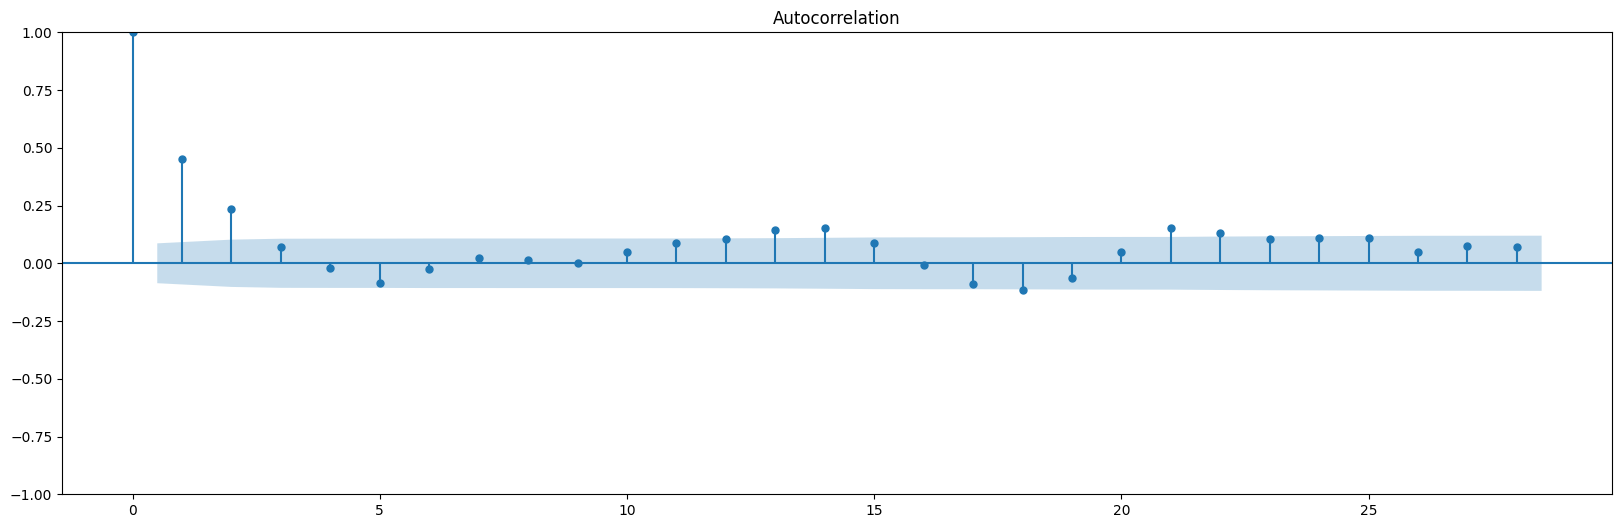

In [70]:
plot_acf(agg_sales['Sales_log'])
plt.show()

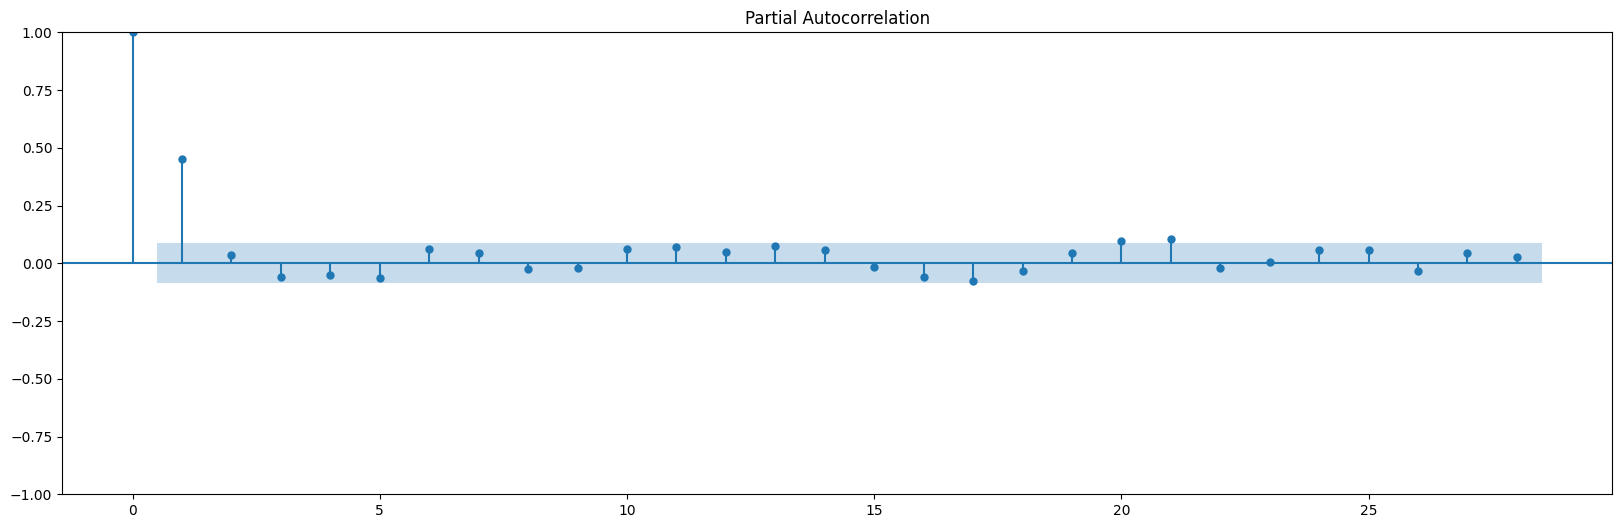

In [71]:
plot_pacf(agg_sales['Sales_log'])
plt.show()

In [72]:
p_value = adfuller(agg_sales['Sales_log'])[1]

if p_value < 0.05:
    print("The time series is stationary")
else:
    print("The time series is non-stationary")

The time series is stationary


In [73]:
train_max_date = agg_sales.index[-14]
train_x = agg_sales.loc[agg_sales.index < agg_sales.index[-14]].copy()
test_x = agg_sales.loc[agg_sales.index >= agg_sales.index[-14]].copy()

In [74]:
import statsmodels as sm
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [75]:
model_with_exog = SARIMAX(train_x['Sales_log'], order = (1, 1, 1), seasonal_order = (0, 1, 1, 7), exog = train_x[['Holiday']]
                          , enforce_stationarity=False, enforce_invertibility=False)
model_with_exog = model_with_exog.fit(disp = False, max_iter = 200)

In [76]:
model_without_exog = SARIMAX(train_x['Sales_log'], order = (1, 1, 1), seasonal_order = (0, 1, 1, 7),
                             enforce_stationarity=False, enforce_invertibility=False)
model_without_exog = model_without_exog.fit(disp = False, max_iter = 200)

In [77]:
print("\nModel Summary with Exogenous Variable")
print(model_with_exog.summary())


Model Summary with Exogenous Variable
                                     SARIMAX Results                                     
Dep. Variable:                         Sales_log   No. Observations:                  502
Model:             SARIMAX(1, 1, 1)x(0, 1, 1, 7)   Log Likelihood                   0.973
Date:                           Sat, 18 Apr 2026   AIC                              8.055
Time:                                   11:34:26   BIC                             28.975
Sample:                                        0   HQIC                            16.274
                                           - 502                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Holiday       -0.2454      0.029     -8.345      0.000      -0.303      -0.188
ar.L

In [78]:
print("\nModel Summary without Exogenous Variable")
print(model_without_exog.summary())


Model Summary without Exogenous Variable
                                     SARIMAX Results                                     
Dep. Variable:                         Sales_log   No. Observations:                  502
Model:             SARIMAX(1, 1, 1)x(0, 1, 1, 7)   Log Likelihood                 -28.186
Date:                           Sat, 18 Apr 2026   AIC                             64.372
Time:                                   11:34:26   BIC                             81.108
Sample:                                        0   HQIC                            70.948
                                           - 502                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.4300      0.020     21.093      0.000       0.390       0.470
m

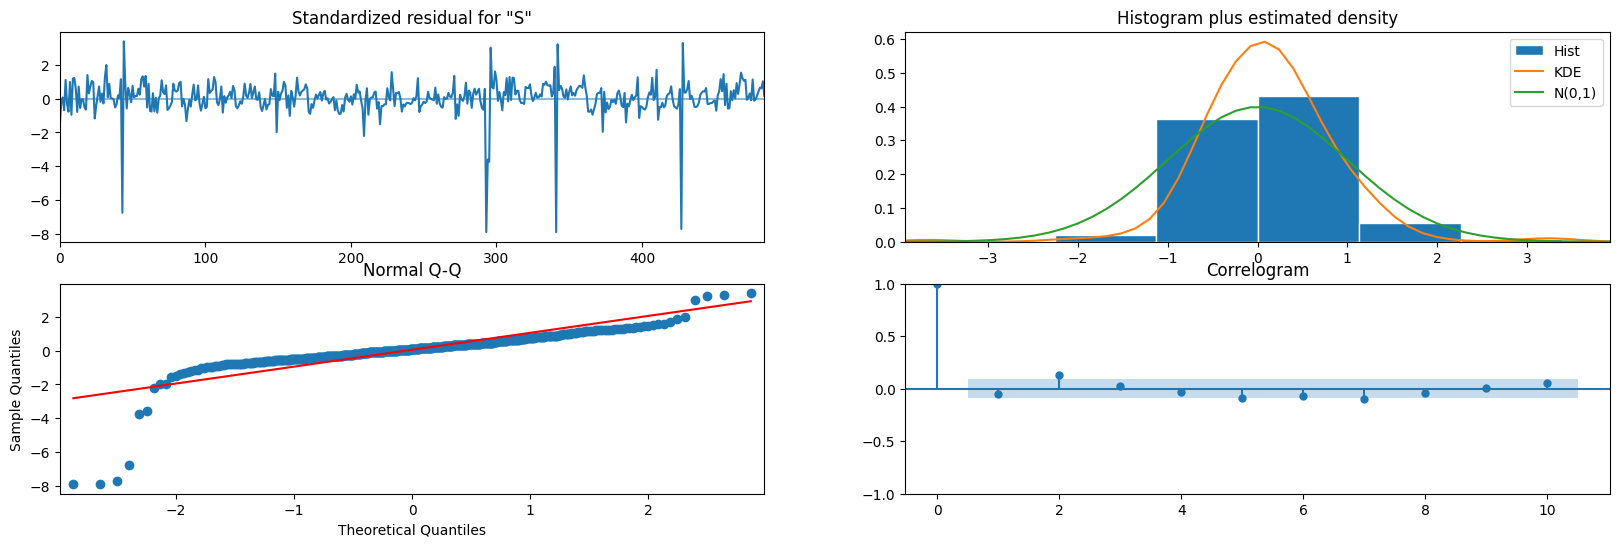

In [79]:
model_with_exog.plot_diagnostics()
plt.show()

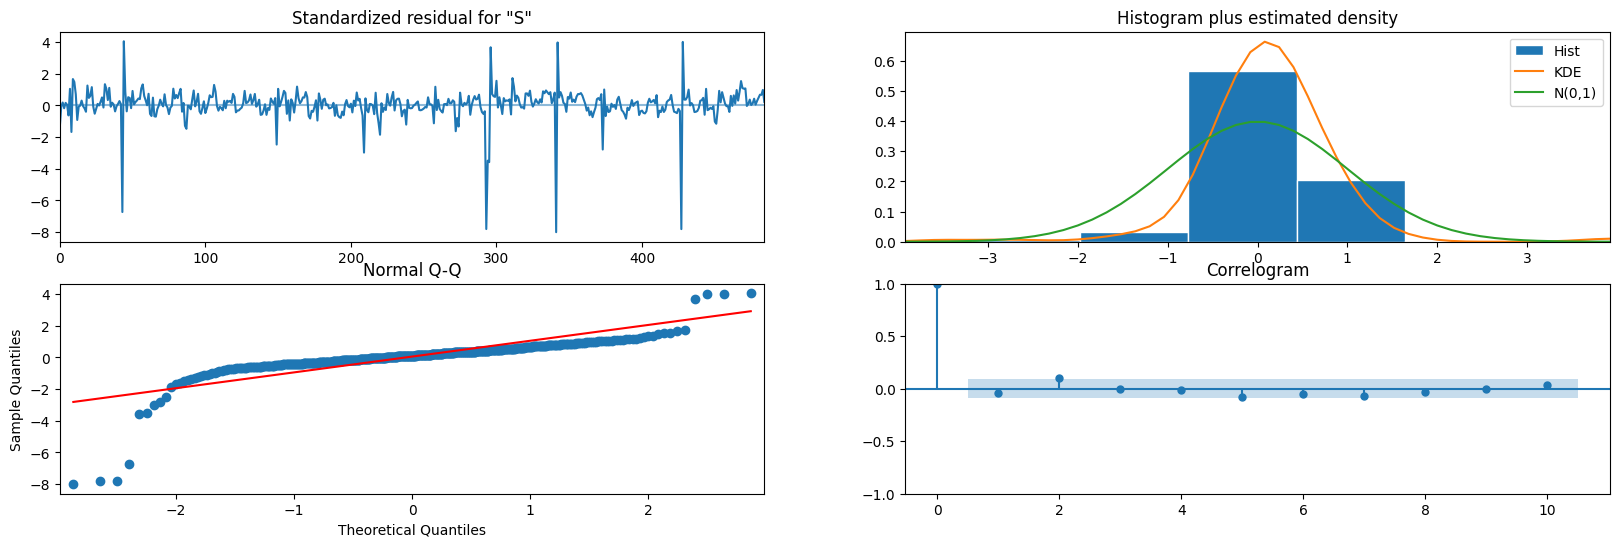

In [80]:
model_without_exog.plot_diagnostics()
plt.show()

In [81]:
forecast_without_exog = model_without_exog.get_forecast(steps=14)
pred_without_exog = np.exp(forecast_without_exog.predicted_mean)
conf_int_without_exog = np.exp(forecast_without_exog.conf_int())

In [82]:
forecast_with_exog = model_with_exog.get_forecast(steps=14, exog=test_x['Holiday'])
pred_with_exog = np.exp(forecast_with_exog.predicted_mean)
conf_int_with_exog = np.exp(forecast_with_exog.conf_int())

In [83]:
cutoff_date = agg_sales.Date.max() - pd.DateOffset(days=20)

train_f = train_x[train_x['Date'] >= cutoff_date]
test_f = test_x[test_x['Date'] >= cutoff_date]

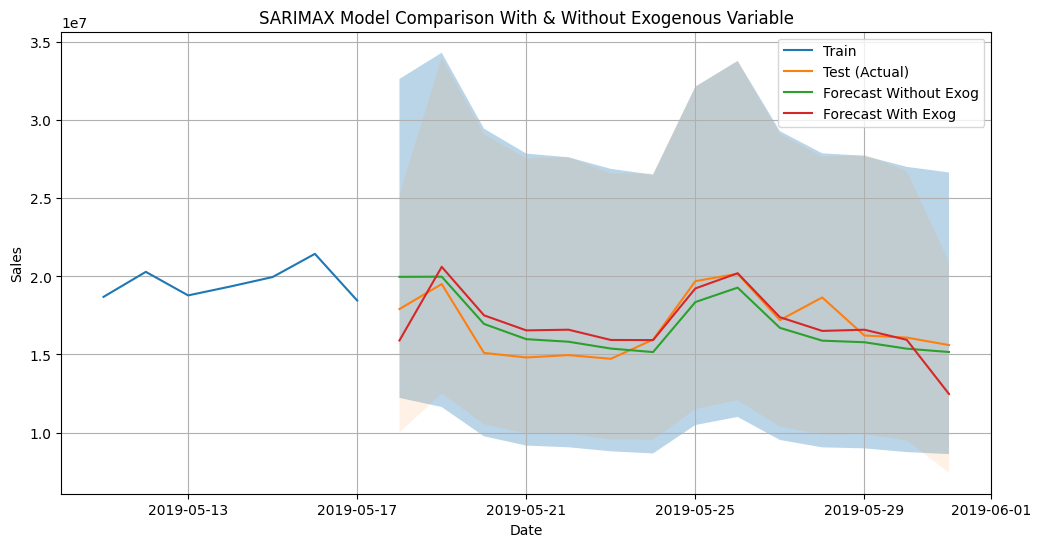

In [84]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12,6))

plt.plot(train_f['Date'], train_f['Sales'], label='Train')
plt.plot(test_f['Date'], test_f['Sales'], label='Test (Actual)')
plt.plot(test_x['Date'], pred_without_exog, label='Forecast Without Exog')
plt.plot(test_x['Date'], pred_with_exog, label='Forecast With Exog')
plt.fill_between(test_x['Date'], conf_int_without_exog.iloc[:, 0], conf_int_without_exog.iloc[:, 1],alpha=0.3)
plt.fill_between(test_x['Date'], conf_int_with_exog.iloc[:, 0], conf_int_with_exog.iloc[:, 1],alpha=0.1)
plt.title("SARIMAX Model Comparison With & Without Exogenous Variable")
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.grid()
plt.show()

In [85]:
print(f"SARIMAX MAPE With Exog : {round(mean_absolute_percentage_error(test_f['Sales'], pred_with_exog) * 100, 4)} %")
print(f"SARIMAX MSE With Exog : {mean_squared_error(test_f['Sales'], pred_with_exog):,.2f}")
print(f"SARIMAX MAE With Exog : {mean_absolute_error(test_f['Sales'], pred_with_exog):,.2f}")
print(f"SARIMAX RMSE With Exog : {np.sqrt(mean_squared_error(test_f['Sales'], pred_with_exog)):,.2f}")

SARIMAX MAPE With Exog : 7.3012 %
SARIMAX MSE With Exog : 2,358,373,855,845.28
SARIMAX MAE With Exog : 1,186,032.04
SARIMAX RMSE With Exog : 1,535,699.79


In [86]:
print(f"SARIMAX MAPE Without Exog : {round(mean_absolute_percentage_error(test_f['Sales'], pred_without_exog) * 100, 4)} %")
print(f"SARIMAX MSE Without Exog : {mean_squared_error(test_f['Sales'], pred_without_exog):,.2f}")
print(f"SARIMAX MAE Without Exog : {mean_absolute_error(test_f['Sales'], pred_without_exog):,.2f}")
print(f"SARIMAX RMSE Without Exog : {np.sqrt(mean_squared_error(test_f['Sales'], pred_without_exog)):,.2f}")

SARIMAX MAPE Without Exog : 6.2982 %
SARIMAX MSE Without Exog : 1,605,208,683,930.32
SARIMAX MAE Without Exog : 1,067,837.03
SARIMAX RMSE Without Exog : 1,266,968.30


Here as we have see from above mentioned few cell that we try adopting different model for get our forecast for coming days. Considering our different model performance and based on different hyper-parameter tuning we found that SARIMAX without exogenous variable provided best performance when compared with Linear Regression or LGBM or SARIMAX considering exogenous variable.

Here we did bring multiple evaluation techniques for find which model will be best in projecting future forecast numbers for the sales. Few of them are MAPE (Mean Absolute Percentage Error), MSE (Mean Squared Error), MAE (Mean Absolute Error) and final RMSE (Root Mean Squared Error). Based on all these evaluation parameters we found out our SARIMAX model based on without exogenous variable shows best performance.

SARIMAX -> (p,d,q) = (1,1,1) and (P,D,Q,s) = (0,1,1,7)

For finding values of p,d,q along with P,D,Q,s we did ran few test such as ADF (Augumented Ducky Fuller test - Check stationary), for making series more homoscedastic we did log of sales, plotted ACF (Auto-correlation function) and PACF (Partial-Autocorrelation function) which helps us find best values.
Later along below code we also did check our model performance by running forward walk so to see how our model is preforming based on un-seen data points.

Model Config:

MAPE: 6.3%, MSE: 1605208683930.3, MAE: 1067837.03, RMSE: 1266968.3 and Rolling Median MAPE: 13.68%

We are goo to use this model but if we have improve more over MAPE value then more number of observations are required

In [87]:
start_point = int(len(agg_sales) * 0.75)
horizon = 14
step = 14
max_iter = 50

mape_scores = []
mae_scores = []
mse_scores = []
rmse_scores = []

for i in range(start_point, len(agg_sales) - horizon, step):

    train = agg_sales.iloc[:i]
    test = agg_sales.iloc[i:i+horizon]

    try:
        model = SARIMAX(train['Sales_log'], order=(1,1,1), seasonal_order=(0,1,1,7),enforce_stationarity=False, enforce_invertibility=False)
        model_fit = model.fit(disp=False, maxiter=max_iter)
        forecast = model_fit.get_forecast(steps=horizon)
        pred = np.exp(forecast.predicted_mean)

        mae = mean_absolute_error(test['Sales'], pred)
        mse = mean_squared_error(test['Sales'], pred)
        rmse = np.sqrt(mse)
        mape = mean_absolute_percentage_error(test['Sales'], pred)
        mape_scores.append(mape)
        mae_scores.append(mae)
        mse_scores.append(mse)
        rmse_scores.append(rmse)
    except:
        continue

In [88]:
print(f"\nModel Cross-Validation Results:")
print(f"MAPE per window: {np.round(mape_scores, 4) * 100}")
print(f"Avg MAPE: {round(np.mean(mape_scores), 4) * 100} %" )
print(f"Median MAPE: {round(np.median(mape_scores), 4) * 100} %")
print()
print("=" * 30)
print()
print(f"MAE per window: {np.round(mae_scores, 2)}")
print(f"Avg MAE: {round(np.mean(mae_scores), 2)}" )
print(f"Median MAE: {round(np.median(mae_scores), 2)}")
print()
print("=" * 30)
print()
print(f"MSE per window: {np.round(mse_scores, 2)}")
print(f"Avg MSE: {round(np.mean(mse_scores), 2)}" )
print(f"Median MSE: {round(np.median(mse_scores), 2)}")
print()
print("=" * 30)
print()
print(f"RMSE per window: {np.round(rmse_scores, 2)}")
print(f"Avg RMSE: {round(np.mean(rmse_scores), 2)}" )
print(f"Median RMSE: {round(np.median(rmse_scores), 2)}")


Model Cross-Validation Results:
MAPE per window: [15.21 10.85 13.68 11.85 56.78 15.03 13.59 24.03  9.52]
Avg MAPE: 18.95 %
Median MAPE: 13.68 %


MAE per window: [2011679.67 1510081.37 1943507.72 1679710.21 2499459.23 1950372.14
 2321195.58 4957031.27 1812203.92]
Avg MAE: 2298360.12
Median MAE: 1950372.14


MSE per window: [7.53181012e+12 3.47764731e+12 4.56072648e+12 3.41199633e+12
 1.38204886e+13 6.29512987e+12 8.10792833e+12 3.14839822e+13
 6.05454466e+12]
Avg MSE: 9416028217023.85
Median MSE: 6295129868056.35


RMSE per window: [2744414.35 1864845.12 2135585.75 1847158.99 3717591.78 2509009.74
 2847442.42 5611058.92 2460598.44]
Avg RMSE: 2859745.05
Median RMSE: 2509009.74


In [89]:
import pickle

with open("model.pkl", "wb") as f:
    pickle.dump(model_fit, f)